In [1]:
%load_ext autoreload
%autoreload 2

# Disconnection or Real mPFC Activity?

In [2]:
import sys
import os
import tdt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.signal import find_peaks
from rc_extension import Reward_Competition
from Reward_Training.rt_extension import Reward_Training

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [3]:
experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts"
manual_scoring_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\manual_scoring_combined.xlsx"
hvl_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\HvL_comp_scoring_updated.xlsx"
"""experiment_path = r"D:\PadillaCoreanoLab\Reward_Competition\combined_cohorts"
manual_scoring_path = r"D:\PadillaCoreanoLab\Reward_Competition\combined_cohorts\manual_scoring_combined.xlsx"
hvl_path = r"D:\PadillaCoreanoLab\Reward_Competition\combined_cohorts\HvL_comp_scoring_updated.xlsx"""

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\yezon\AppData\Local\Temp\ipykernel_20324\692247188.py:4: SyntaxWarning: invalid escape sequence '\P'
  """experiment_path = r"D:\PadillaCoreanoLab\Reward_Competition\combined_cohorts"


'experiment_path = r"D:\\PadillaCoreanoLab\\Reward_Competition\\combined_cohorts"\nmanual_scoring_path = r"D:\\PadillaCoreanoLab\\Reward_Competition\\combined_cohorts\\manual_scoring_combined.xlsx"\nhvl_path = r"D:\\PadillaCoreanoLab\\Reward_Competition\\combined_cohorts\\HvL_comp_scoring_updated.xlsx'

In [4]:
# rt_mPFC_experiment_path = r"D:\PadillaCoreanoLab\Reward_Training\Combined\Day10\mPFC"
# rt_NAc_experiment_path = r"D:\PadillaCoreanoLab\Reward_Training\Combined\Day10\NAc"

## Preprocessing

In [5]:
rc_exp = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=None)
rc_exp.rtc_processing()
rc_exp.read_and_merge_manual_scoring(manual_scoring_path)
rc_exp.remove_specified_subjects()   # Remove specified subjects from the analysis
rc_exp.read_hvl_scoring(hvl_path)
rc_exp.remove_tangles(placeholders= True)   # Remove sound cues and winner array indexes where there are tangles
rc_exp.extract_da_columns()   # Grab only essential columns for analysis
rc_exp.find_first_port_entry_after_sound_cue()
rc_exp.compute_EI_DA(tone_window=(-5,10),
                  pe_window=(0,10),
                  baseline_window=(-20,-10))
rc_exp.compute_pretrial_EI_DA(pretrial_window=(-10,0),
                  baseline_window=(-14,-10))
rc_exp.compute_rtc_da_metrics(include_pretrial=True, bout_duration=4).head()
# rc_exp.remove_tangles() 

Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts\n5-240912-080246\Notes.txt
read from t=0s to t=2051.77s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts\n5-240913-094304\Notes.txt
read from t=0s to t=2044.77s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts\n5-240915-060250\Notes.txt
read from t=0s to t=2044.96s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts\n5-240915-095000\Notes.txt
read from t=0s to t=2070.66s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections\combined_cohorts\n7-240912-095235\Notes.txt
read from t=0s to t=1955.86s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for di

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\Reward_Training_Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\Reward_Training_Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce

,subject_name,file name,trial,filtered_sound_cues,filtered_port_entries,filtered_port_entry_offset,filtered_winner_array,HVL_PreComp,HVL_Comp,first_PE_after_sound_cue,...,Tone Time of Max Peak,Tone Mean Z-score,PE AUC,PE Max Peak,PE Time of Max Peak,PE Mean Z-score,Pretrial AUC,Pretrial Max Peak,Pretrial Time of Max Peak,Pretrial Mean Z-score
0,nn5,nn5-250203-080636,<trial_class.Trial object at 0x000001E1A6454650>,"[241.12775168, 321.12836608, 411.12895488, 491...","[184.1774592, 185.80733952, 193.31743744, 285....","[184.47745024, 187.45769984, 193.45752064, 285...","[tie, nn8, nn8, nn8, nn8, nn8, nn8, nn8, nn8, ...","[nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[285.35799808, 325.12836608, 415.12895488, 495...",...,"[0.7599999998637941, 0.7299999998645035, 0.849...","[0.5802336747137268, 1.0628530397409286, 0.351...","[0.6171770231792162, 0.8103694032097739, 1.302...","[1.7444741505890045, 1.0771713947169135, 1.236...","[0.0, 3.329999999921256, 1.729999999959091, 3....","[0.15554037603863283, 0.20191823874917406, 0.3...","[-2.849382550168764, -1.3336872573869143, 0.66...","[0.5931472481063685, 1.0071056302787829, 1.468...","[-8.490000000035707, -3.4200000001555964, -0.8...","[-0.2852658182810076, -0.1337081639029117, 0.0..."
1,pp5,pp5-250203-080636,<trial_class.Trial object at 0x000001E1A643B4D0>,"[241.12775168, 321.12836608, 411.12895488, 491...","[181.1275776, 184.02738176, 185.90744576, 187....","[181.68741888, 185.52766464, 186.98747904, 187...","[pp5, pp5, pp5, pp5, pp8, pp5, pp8, tangle, ta...","[0.0, 0.0, nan, 1.0, 1.0, 0.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, nan, ...","[245.12775168, 325.12836608, 415.12895488, 495...",...,"[1.5599999998448766, 0.30999999987443516, 3.99...","[0.2669676790867533, 0.1852523567749728, -0.63...","[5.950139337912823, 0.014127306905708237, 2.29...","[2.8878636660121964, 1.4146806890091848, 1.390...","[1.6799999999602733, 2.769999999934498, 3.5499...","[1.486451562915203, 0.0022014073336268122, 0.5...","[1.8332802116328355, 1.7517189334442307, 2.378...","[1.4933537085859405, 1.404225722707683, 2.0700...","[-2.9000000001678927, -9.35000000001537, -6.44...","[0.1830518255475024, 0.1757293702764755, 0.237..."
2,nn1,nn1-250203-085508,<trial_class.Trial object at 0x000001E1A60DBCB0>,"[250.00820736, 330.00865792, 420.00941056, 500...","[194.11779584, 203.48796928, 215.75778304, 217...","[196.25771008, 206.667776, 217.06801152, 217.8...","[nn2, nn1, nn1, nn1, nn1, nn1, nn2, nn2, nn1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, 0.0, ...","[254.00820736, 334.00865792, 424.00941056, 504...",...,"[1.7699999998399107, 0.7599999998637941, 0.919...","[-0.5260376430763154, 0.7905916884713389, 0.63...","[-0.38772886319409317, 3.201734063472012, 1.82...","[0.4053416088639346, 4.294016009135805, 2.3342...","[2.0799999999508145, 0.8999999999787178, 0.829...","[-0.09679108789204786, 0.7968868844887507, 0.4...","[-6.219682915576498, -4.024362126982294, -5.54...","[1.4058687016702707, 0.7591264878106921, 2.433...","[-9.640000000008513, -9.910000000002128, -6.30...","[-0.6218682903413478, -0.4018647191271188, -0...."
3,nn3,nn3-250203-085508,<trial_class.Trial object at 0x000001E1A4BBB3E0>,"[250.00820736, 330.00865792, 420.00941056, 500...","[219.1179776, 230.92805632, 231.34830592, 244....","[225.37814016, 231.26818816, 232.78813184, 246...","[nn3, nn4, nn3, nn4, nn4, nn4, nn4, nn4, nn4, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[254.00820736, 334.00865792, 424.00941056, 504...",...,"[0.8099999998626117, 0.71999999986474, 0.69999...","[1.9646313990298285, 0.9896661193221952, 2.228...","[9.073446319493542, 1.5730904070593548, 10.878...","[5.7039152776901885, 1.2824150996300059, 7.441...","[1.1599999999725696, 2.599999999938518, 1.0599...","[2.265042353999151, 0.39369404810126674, 2.714...","[-6.01783543321439

## Tone Onsets Quick Check

In [6]:
"""times = rc_exp.da_df.loc[
    rc_exp.da_df['file name'] == 'pp4-250206-093423',
    'filtered_sound_cues'
].iloc[0]

formatted_times = [f"{int(t//60)}:{int(t%60):02d}" for t in times]
print(times)
print(formatted_times)"""

'times = rc_exp.da_df.loc[\n    rc_exp.da_df[\'file name\'] == \'pp4-250206-093423\',\n    \'filtered_sound_cues\'\n].iloc[0]\n\nformatted_times = [f"{int(t//60)}:{int(t%60):02d}" for t in times]\nprint(times)\nprint(formatted_times)'

In [7]:
"""rt_NAc_exp = Reward_Training(experiment_folder_path=rt_NAc_experiment_path, behavior_folder_path=None)
rt_NAc_exp.rtc_processing()
rt_NAc_exp.create_base_df(rt_NAc_experiment_path)
rt_NAc_exp.remove_specified_subjects()
rt_NAc_exp.extract_da_columns()
rt_NAc_exp.find_first_port_entry_after_sound_cue()
rt_NAc_exp.compute_EI_DA()
rt_NAc_exp.compute_rtc_da_metrics()

rt_mPFC_exp = Reward_Training(experiment_folder_path=rt_mPFC_experiment_path, behavior_folder_path=None)
rt_mPFC_exp.rtc_processing()
rt_mPFC_exp.create_base_df(rt_mPFC_experiment_path)
rt_mPFC_exp.remove_specified_subjects()
rt_mPFC_exp.extract_da_columns()
rt_mPFC_exp.find_first_port_entry_after_sound_cue()
rt_mPFC_exp.compute_EI_DA()
rt_mPFC_exp.compute_rtc_da_metrics()"""

'rt_NAc_exp = Reward_Training(experiment_folder_path=rt_NAc_experiment_path, behavior_folder_path=None)\nrt_NAc_exp.rtc_processing()\nrt_NAc_exp.create_base_df(rt_NAc_experiment_path)\nrt_NAc_exp.remove_specified_subjects()\nrt_NAc_exp.extract_da_columns()\nrt_NAc_exp.find_first_port_entry_after_sound_cue()\nrt_NAc_exp.compute_EI_DA()\nrt_NAc_exp.compute_rtc_da_metrics()\n\nrt_mPFC_exp = Reward_Training(experiment_folder_path=rt_mPFC_experiment_path, behavior_folder_path=None)\nrt_mPFC_exp.rtc_processing()\nrt_mPFC_exp.create_base_df(rt_mPFC_experiment_path)\nrt_mPFC_exp.remove_specified_subjects()\nrt_mPFC_exp.extract_da_columns()\nrt_mPFC_exp.find_first_port_entry_after_sound_cue()\nrt_mPFC_exp.compute_EI_DA()\nrt_mPFC_exp.compute_rtc_da_metrics()'

## RC - mPFC - Plot Raw Traces

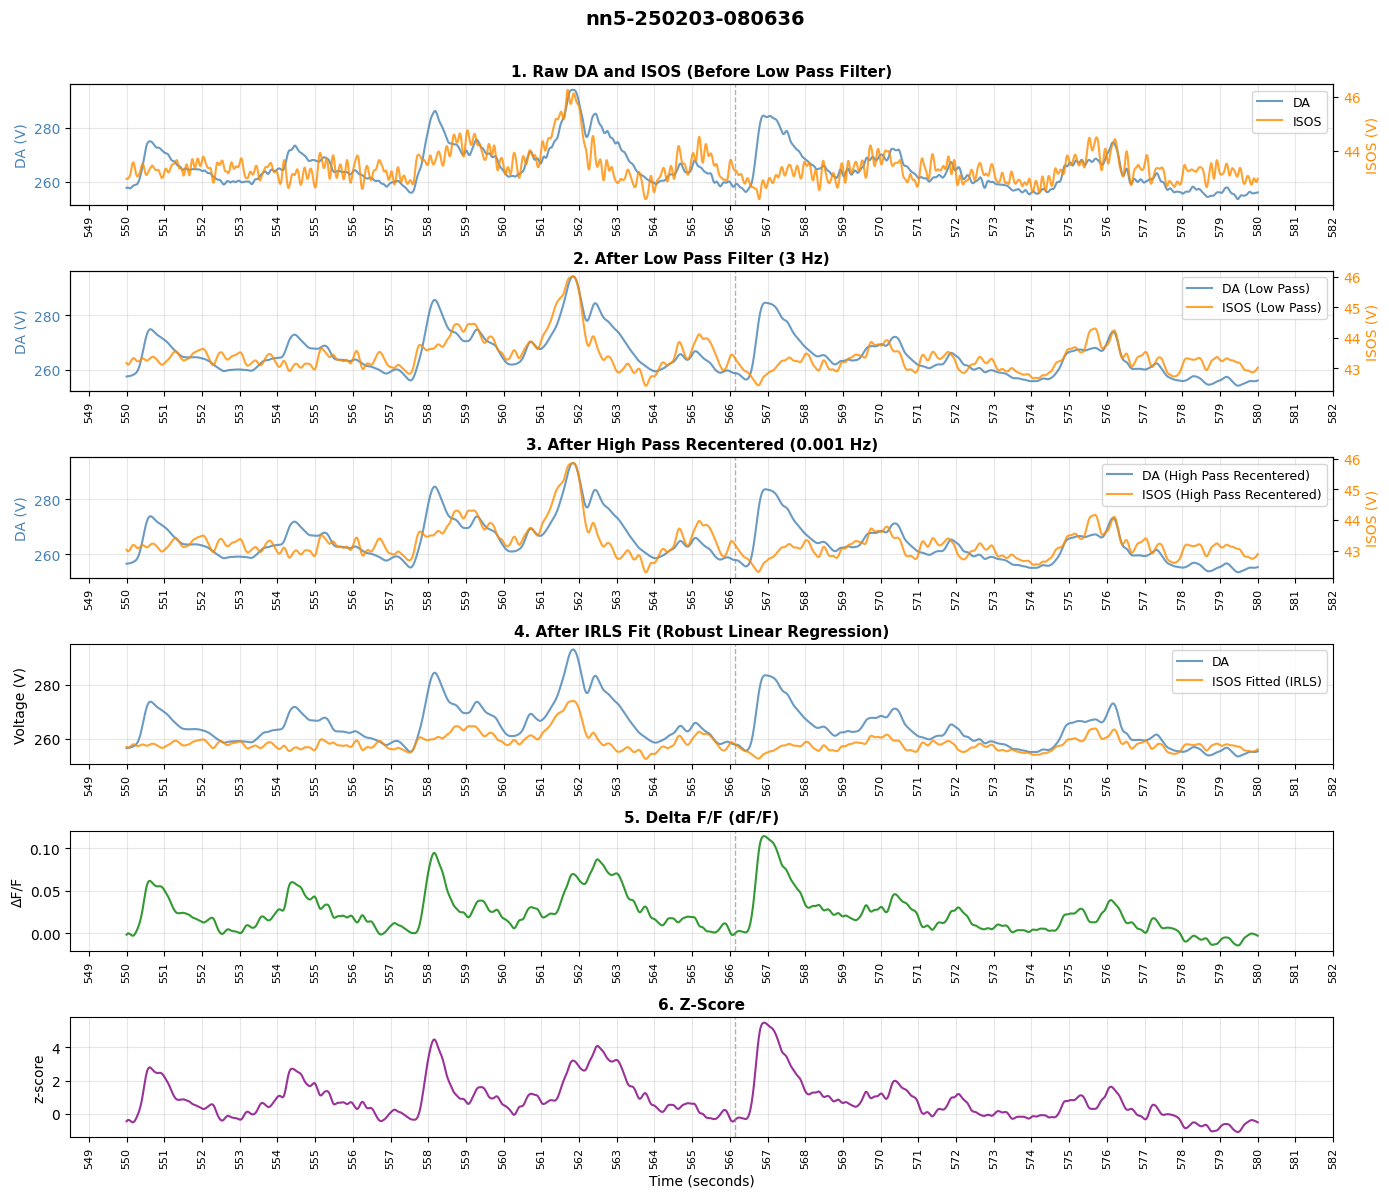

In [8]:
rc_exp.plot_trial_by_name('nn5-250203-080636', start_time=550, end_time=580)

In [9]:
# rc_exp.plot_PETH_index_grid(rc_exp.da_df, event_type='Tone', event_index=1, brain_region='mPFC',)

Figures will be saved to: C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections


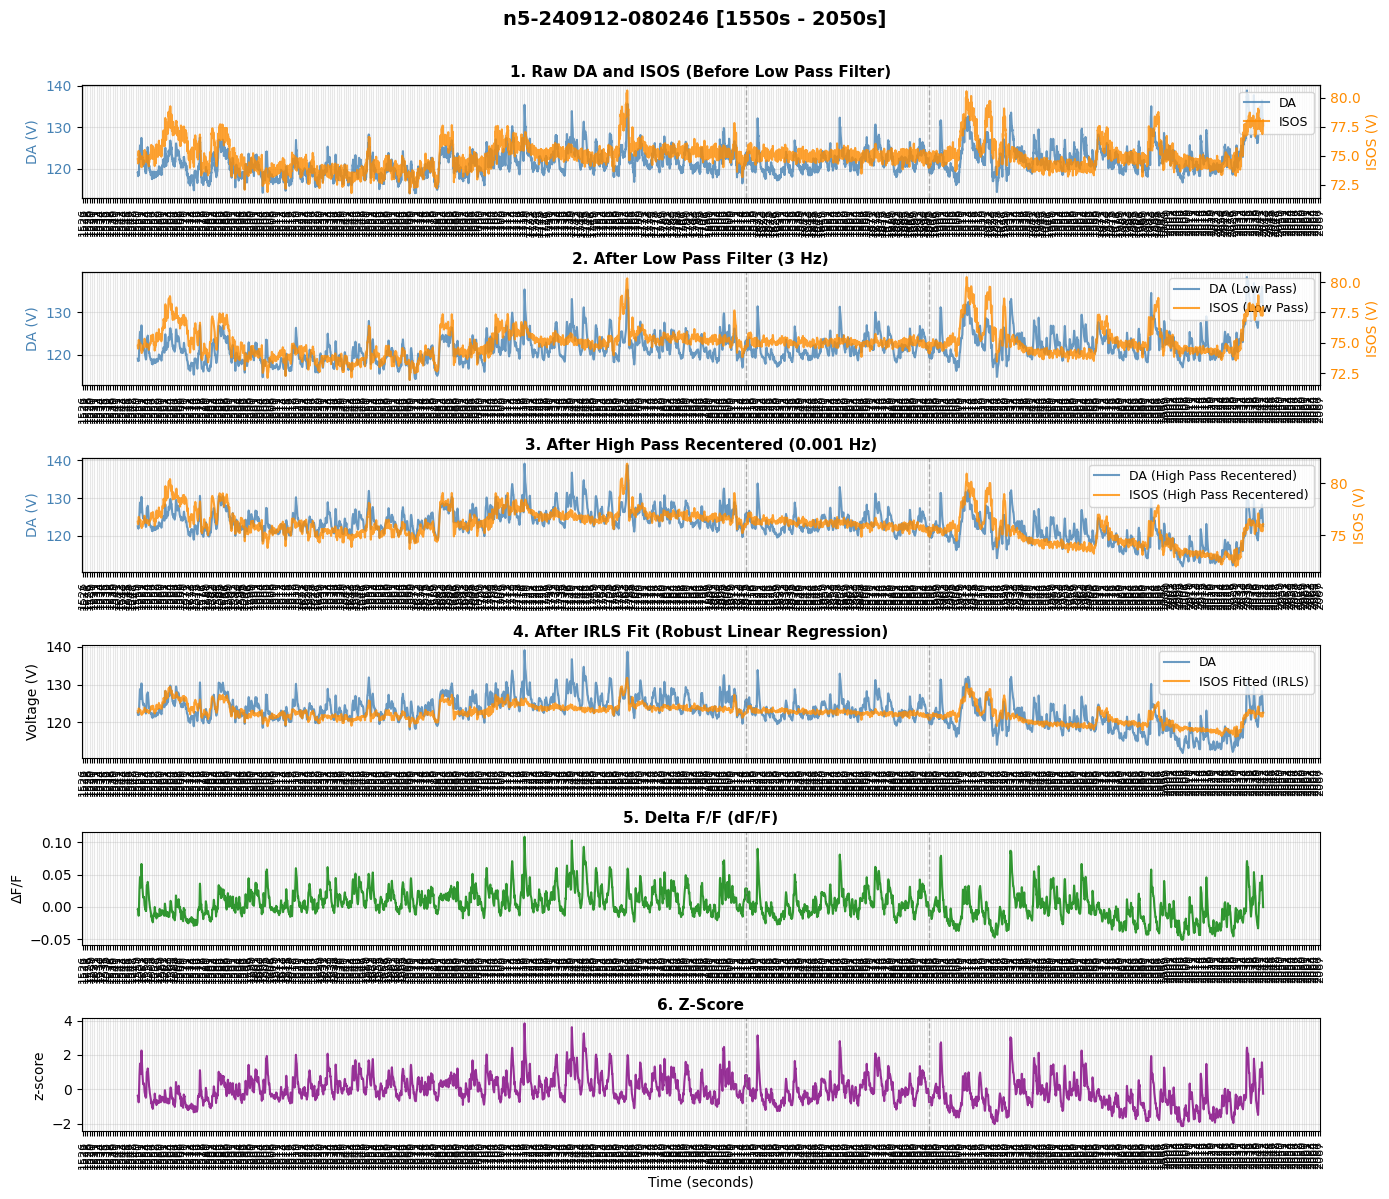

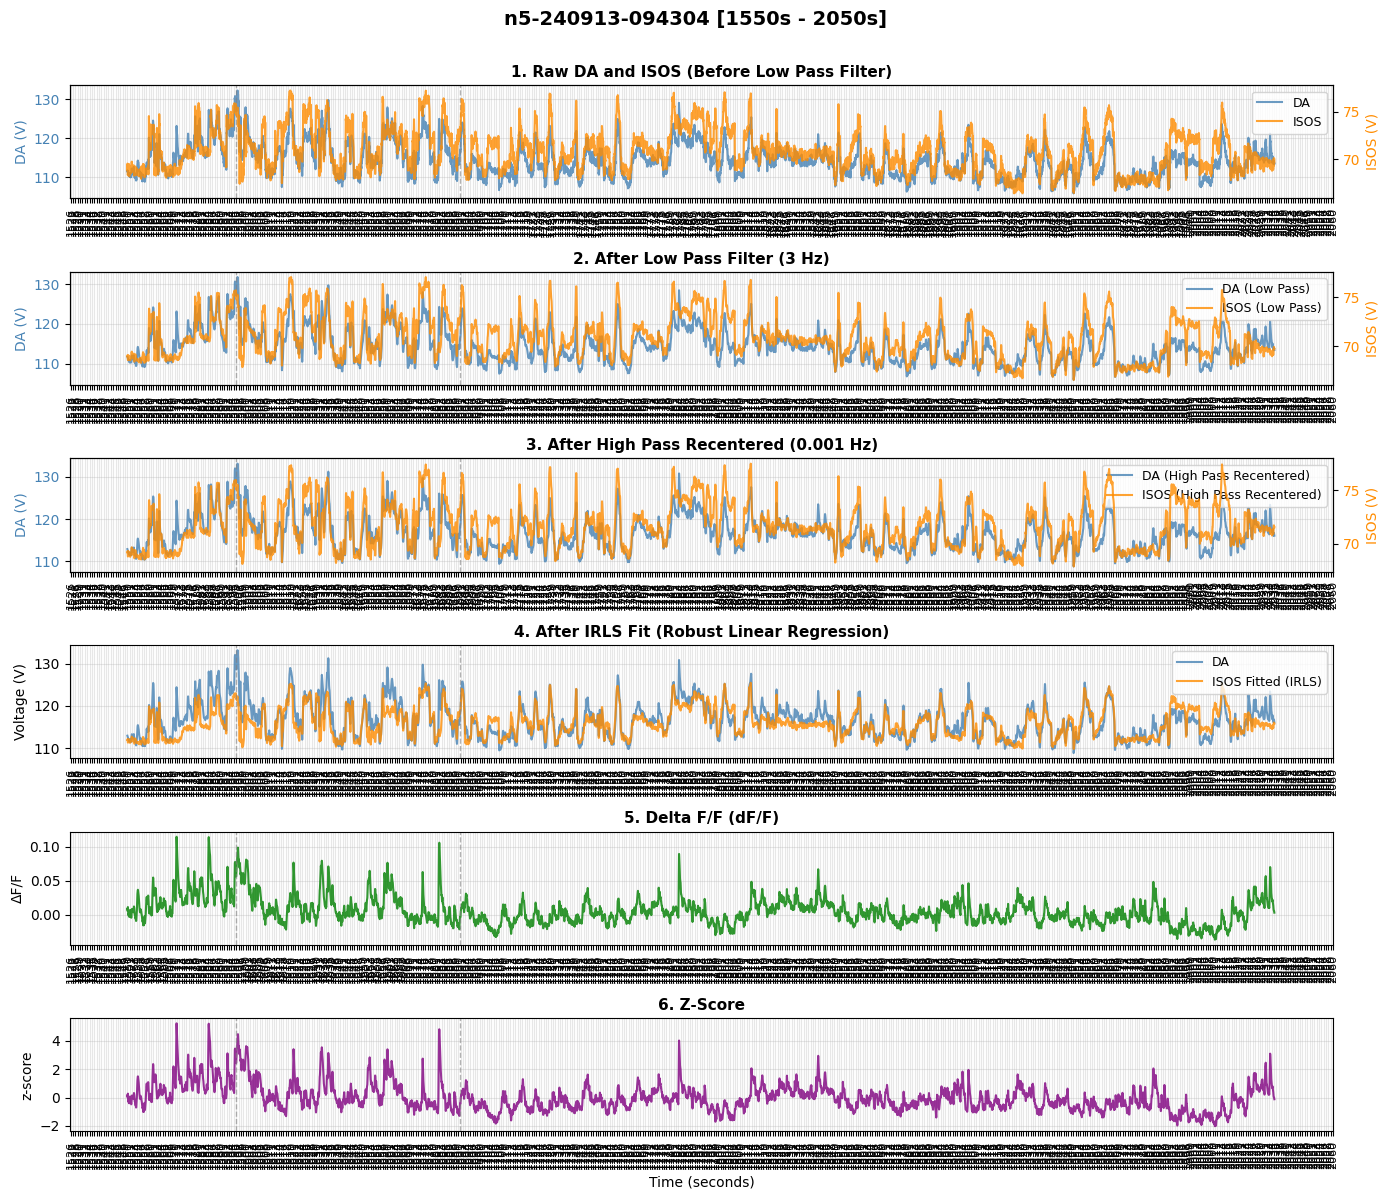

KeyboardInterrupt: 

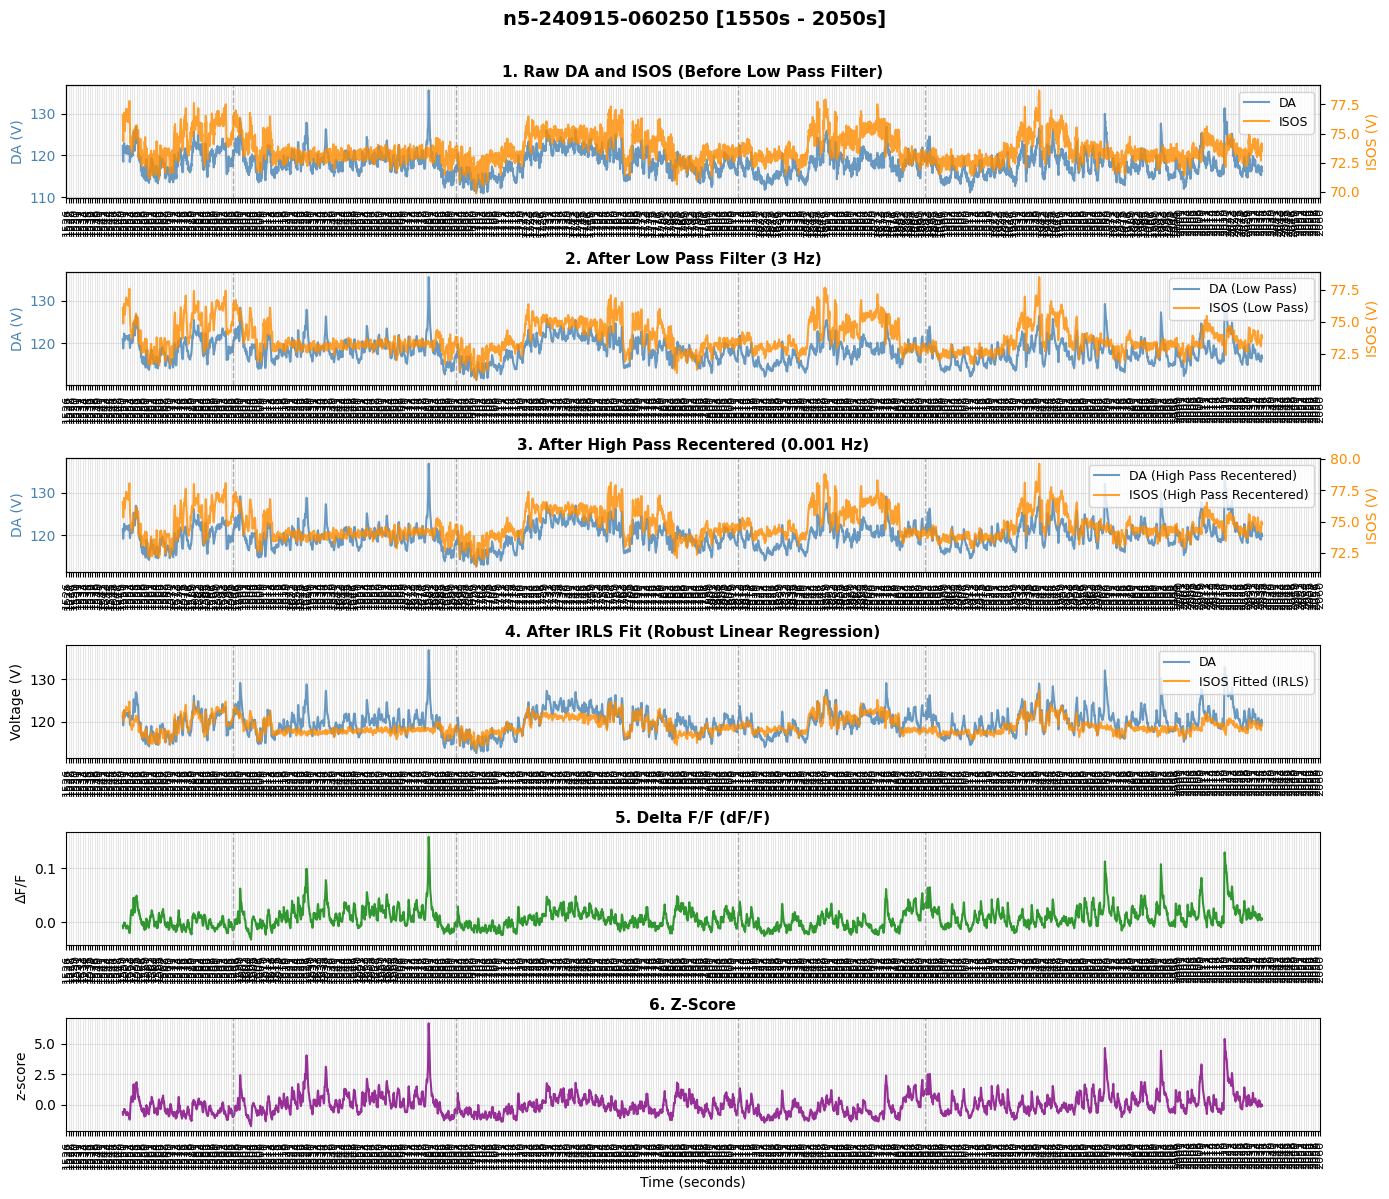

In [10]:
rc_exp.plot_all_processing_progressions(save_directory = r"C:\Users\yezon\Padilla-Coreano_Lab\Fiber Photometry\Troublshoot for disconnections",
										brain_region='NAc',
										start_time=1550,
										end_time=2050)

## RC - NAc - Plot Raw Traces

In [ ]:
# rc_exp.plot_all_processing_progressions(save_directory = r'C:\Users\zhaoz\Desktop\Research\Dopamine Project\RC NAc Processing Traces', brain_region='NAc')

## RT - mPFC - Plot Raw Traces

In [ ]:
#rt_mPFC_exp.plot_all_processing_progressions(save_directory = r'C:\Users\zhaoz\Desktop\Research\Dopamine Project\RT mPFC Processing Traces',
#											 brain_region='mPFC',
#											 start_time=750,
#											 end_time=1000)

## RT - NAc - Plot Raw Traces

In [ ]:
#rt_NAc_exp.plot_all_processing_progressions(save_directory = r'C:\Users\zhaoz\Desktop\Research\Dopamine Project\RT NAc Processing Traces', brain_region='NAc')

## Raw PC0 Channel Data Extraction

Extract the raw hardware PC0 behavioral channel from TDT files to prove the clustering exists in source data

In [ ]:
"""# Extract and print raw PC0 tone onsets for ALL recordings
print("\n" + "="*80)
print("RAW PC0 TONE ONSETS FOR ALL RECORDINGS")
print("="*80)

# Get all unique file names from rc_exp
all_files = rc_exp.da_df['file name'].unique()

print(f"\nTotal recordings: {len(all_files)}\n")

# Loop through all files and print their raw PC0 onsets
for file_name in sorted(all_files):
    # Extract datetime portion (last part after the last dash)
    # e.g., "pp8-250205-095320" -> "250205-095320"
    parts = file_name.split('-')
    if len(parts) >= 2:
        datetime_str = '-'.join(parts[-2:])  # Get last two parts (YYMMDD-HHMMSS)
    else:
        datetime_str = file_name
    
    # Try to find matching folder in experiment_path that ends with this datetime
    tdtdata = None
    
    # List all folders in experiment_path and check if any ends with the datetime string
    for folder_name in os.listdir(experiment_path):
        folder_path = os.path.join(experiment_path, folder_name)
        if os.path.isdir(folder_path) and folder_name.endswith(datetime_str):
            try:
                tdtdata = tdt.read_block(folder_path, verbose=False)
                break
            except:
                continue
    
    # Process if we successfully loaded TDT data
    if tdtdata is not None:
        try:
            # Get PC0 raw data
            pc0_epoc = tdtdata.epocs['PC0_']
            raw_onsets = np.array(pc0_epoc.onset)
            
            # Skip first entry and filter to valid times (>= 200s)
            raw_onsets_clean = raw_onsets[1:] if len(raw_onsets) > 1 else raw_onsets
            raw_onsets_valid = np.array([t for t in raw_onsets_clean if t >= 200])
            
            # Compute intervals
            if len(raw_onsets_valid) > 1:
                intervals_raw = np.diff(raw_onsets_valid)
                clustered_raw = intervals_raw[intervals_raw < 10]
                normal_raw = intervals_raw[intervals_raw >= 80]
                
                # Format output
                cluster_status = "⚠️ CLUSTERED" if len(clustered_raw) > 0 else "✓ normal"
                print(f"RAW {file_name:30s} | {len(raw_onsets_valid):2d} cues | Normal: {len(normal_raw):2d}, Clustered: {len(clustered_raw):2d} | {cluster_status}")
            else:
                print(f"RAW {file_name:30s} | {len(raw_onsets_valid):2d} cues | (insufficient data)")
        except Exception as e:
            print(f"RAW {file_name:30s} | ❌ Error processing PC0: {str(e)}")
    else:
        print(f"RAW {file_name:30s} | ❌ Error: block path not found")
        
	# Check clusters in filtered_sound_cue
    filtered_onsets_valid = rc_exp.da_df.loc[rc_exp.da_df['file name'] == file_name, 'filtered_sound_cues'].iloc[0]
    intervals_filtered = np.diff(filtered_onsets_valid)
    clustered_filtered = intervals_filtered[intervals_filtered < 10]
    normal_filtered = intervals_filtered[intervals_filtered >= 80]
    
	# Format output
    cluster_status = "⚠️ CLUSTERED" if len(clustered_filtered) > 0 else "✓ normal"
    print(f"Filtered {file_name:30s} | {len(filtered_onsets_valid):2d} cues | Normal: {len(normal_filtered):2d}, Clustered: {len(clustered_filtered):2d} | {cluster_status}")
	# Print filtered_sound_cues if there are clusters
    if len(clustered_filtered) > 0:
        print(f"  Filtered cues: {filtered_onsets_valid}")

print("\n" + "="*80)"""

'# Extract and print raw PC0 tone onsets for ALL recordings\nprint("\n" + "="*80)\nprint("RAW PC0 TONE ONSETS FOR ALL RECORDINGS")\nprint("="*80)\n\n# Get all unique file names from rc_exp\nall_files = rc_exp.da_df[\'file name\'].unique()\n\nprint(f"\nTotal recordings: {len(all_files)}\n")\n\n# Loop through all files and print their raw PC0 onsets\nfor file_name in sorted(all_files):\n    # Extract datetime portion (last part after the last dash)\n    # e.g., "pp8-250205-095320" -> "250205-095320"\n    parts = file_name.split(\'-\')\n    if len(parts) >= 2:\n        datetime_str = \'-\'.join(parts[-2:])  # Get last two parts (YYMMDD-HHMMSS)\n    else:\n        datetime_str = file_name\n    \n    # Try to find matching folder in experiment_path that ends with this datetime\n    tdtdata = None\n    \n    # List all folders in experiment_path and check if any ends with the datetime string\n    for folder_name in os.listdir(experiment_path):\n        folder_path = os.path.join(experiment_p